SATFFING PROJECT
The main purpose of this project is to predict the staff needed to work in an hotel in Glasneeving area, this predictions are going to be based on historical Weather, events and ocupancy from the hotel. This predictions will impact to prevent overstaffing and understafing, generating a better distribution of staff, improving customer service and avoiding the waste on salaries. 


WEATHER DATA SET
In this section I imported 3 data sets from MEt Eireann, from 2023, 2024 and 2025, It contains information like rain, max temperature, min temprerature and date, those 4 are the features I need to determin "How a good weather look like". I merged the 3 data sets and I defined this 3 parameters, 1 Good/Warm, 2 Dry/Cool, 3 Poor/Wet. 

In [1]:
#Important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import the 3 data sets from Met Eireann, the sets are clean and organized, the main task here is to merge them and create the conditionals that
#will determine how a good weather looks like to impact the hotel ocupancy
df_15 = pd.read_csv("DataSets/dly1823_subset 2015.csv", skiprows=13)
df_16 = pd.read_csv("DataSets/dly1823_subset 2016.csv", skiprows=13 )
df_17 = pd.read_csv("DataSets/dly1823_subset 2017.csv", skiprows=13)

#Combine into one master weather dataframe, 
df = pd.concat([df_15, df_16, df_17], ignore_index=True)


# Preview the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1096 non-null   object 
 1   ind     1096 non-null   int64  
 2   rain    1096 non-null   float64
 3   ind.1   1096 non-null   int64  
 4   maxt    1096 non-null   float64
 5   ind.2   1096 non-null   int64  
 6   mint    1096 non-null   float64
 7   gmin    1096 non-null   float64
 8   soil    1096 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 77.2+ KB


In [3]:
df.head

<bound method NDFrame.head of              date  ind  rain  ind.1  maxt  ind.2  mint  gmin soil
0     01-jan-2015    0   2.6      0  15.0      0  10.4   8.0     
1     02-jan-2015    0   7.7      0   8.0      0   4.6   3.2     
2     03-jan-2015    0   1.1      0   5.9      0   4.3   3.0     
3     04-jan-2015    4   0.0      0   9.7      1  -1.6  -5.0     
4     05-jan-2015    0   1.1      0  11.6      1  -1.1  -4.1     
...           ...  ...   ...    ...   ...    ...   ...   ...  ...
1091  27-dec-2017    0   0.0      0   4.8      0   1.0  -2.0     
1092  28-dec-2017    0   2.8      0   6.8      1  -0.7  -3.6     
1093  29-dec-2017    0  13.9      0   9.4      1  -0.4  -3.1     
1094  30-dec-2017    0   0.2      0  12.5      0   2.0   0.4     
1095  31-dec-2017    0   0.5      0  12.5      0   7.3   5.1     

[1096 rows x 9 columns]>

In [4]:
df_filtered = df [["date", "rain", "maxt", "mint"]] #Now I'll filter only the freatures that impact my model.
df_filtered.head()

,date,rain,maxt,mint
0,01-jan-2015,2.6,15.0,10.4
1,02-jan-2015,7.7,8.0,4.6
2,03-jan-2015,1.1,5.9,4.3
3,04-jan-2015,0.0,9.7,-1.6
4,05-jan-2015,1.1,11.6,-1.1


In [5]:
df_filtered = df[["date", "rain", "maxt", "mint"]].copy()
conditions = [
    #Good/Warm: Less than 1mm rain AND 16C or warmer
    (df_filtered["rain"] < 1.0) & (df_filtered["maxt"] >= 13),
    
    #Dry/Cool: Less than 1mm rain AND cooler than 16C
    (df_filtered["rain"] < 1.0) & (df_filtered["maxt"] < 13),
    
    #Poor/Wet: 5mm+ of rain OR very cold (under 5C max)
    (df_filtered["rain"] >= 5.0) | (df_filtered["maxt"] < 8),
]

choices = ["Good/Warm", "Dry/Cool", "Poor/Wet"]

# Apply the choices, everything else becomes 'Moderate/Changeable'
df_filtered["weather_quality"] = np.select(conditions, choices, default="Moderate/Changeable")


df_filtered.head(10)


,date,rain,maxt,mint,weather_quality
0,01-jan-2015,2.6,15.0,10.4,Moderate/Changeable
1,02-jan-2015,7.7,8.0,4.6,Poor/Wet
2,03-jan-2015,1.1,5.9,4.3,Poor/Wet
3,04-jan-2015,0.0,9.7,-1.6,Dry/Cool
4,05-jan-2015,1.1,11.6,-1.1,Moderate/Changeable
5,06-jan-2015,0.3,10.0,3.3,Dry/Cool
6,07-jan-2015,5.9,12.9,4.2,Poor/Wet
7,08-jan-2015,2.0,10.5,5.4,Moderate/Changeable
8,09-jan-2015,7.2,15.4,5.4,Poor/Wet
9,10-jan-2015,0.0,6.3,5.6,Dry/Cool


DUBLIN EVENTS DATA SET 
This data set was created with the help of AI to find all the past events from 2015 to 2017 that can impact the Glasneevin area. This data set will help to predict the events that can impact the hotel occupancy. 
I specifically created the list of events with the "date" column in the same format than wetaher data set, so I can merge them together. 

In [6]:
df_events = pd.read_csv("DataSets/dublin_events_2015_2017.csv")
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1096 non-null   object
 1   event_name    1096 non-null   object
 2   event_impact  1096 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 25.8+ KB


In [7]:
df_events.head(10) #first overview of the data set

,date,event_name,event_impact
0,1/1/2015,No Event,0
1,2/1/2015,No Event,0
2,3/1/2015,No Event,0
3,4/1/2015,No Event,0
4,5/1/2015,No Event,0
5,6/1/2015,No Event,0
6,7/1/2015,No Event,0
7,8/1/2015,No Event,0
8,9/1/2015,No Event,0
9,10/1/2015,No Event,0


In [8]:
df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="mixed", dayfirst="TRUE") # I can see all the rows share the same date format so now I can merge based on that
df_events["date"] = pd.to_datetime(df_events["date"], format="mixed", dayfirst="TRUE")
df_merged = pd.merge(df_filtered, df_events, on= "date", how="left")


In [9]:
df_merged["event_impact"] = df_merged["event_impact"].fillna(0) # on the df the days that we dont have events should be marked as 0
df_merged["event_name"] = df_merged["event_name"].fillna("No Event") # and the name as No event, insted of just saying NAN
df_merged.head()
#Event impact 0 means no event, and 1 means we have an event that can impact the bussiness 

,date,rain,maxt,mint,weather_quality,event_name,event_impact
0,2015-01-01,2.6,15.0,10.4,Moderate/Changeable,No Event,0
1,2015-01-02,7.7,8.0,4.6,Poor/Wet,No Event,0
2,2015-01-03,1.1,5.9,4.3,Poor/Wet,No Event,0
3,2015-01-04,0.0,9.7,-1.6,Dry/Cool,No Event,0
4,2015-01-05,1.1,11.6,-1.1,Moderate/Changeable,No Event,0


THE HOTEL DATA SET
This data set contains a data set obtained from Kaggle, based on the first overview I can see that the data corresponds to a different year that I am not focus on, so since this is not a real data set, instead of finding one that belongs to 2023, 2024, and 2025, I'll modify the years to match my events and weather data sets. 
This data set contains many columns that are not align with my other data sets so I'll unify them to try to match dates. 


In [10]:
df_hotel = pd.read_csv("DataSets/hotel_bookings.csv")
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
df_hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [13]:
print("Hotels found in data:", df_hotel["hotel"].unique()) #I can see the set contain more than one hotel, I'll get rid onf one

Hotels found in data: ['Resort Hotel' 'City Hotel']


In [15]:
df_single_hotel = df_hotel[df_hotel["hotel"] == "City Hotel"].copy() # I choose to stay with City Hotel

In [16]:
print("Hotels found in data:", df_single_hotel["hotel"].unique()) # Now I can confirm I only have one hotel to analyse

Hotels found in data: ['City Hotel']


In [17]:
 print(df_single_hotel["arrival_date_year"].unique()) #And I just confirm I have data on the years I need

[2015 2016 2017]


In [18]:
#By looking at the columns I can see that the information I need is in "adults", I only focus on how many people stayed per nigth and I'll include "kids" too
df_single_hotel["total_people"] = df_single_hotel["adults"] + df_single_hotel["children"].fillna(0)

In [19]:
#I mapped the months, since on the data set they have different formatting, I have to reset the dates to make them fit with my other sets
month_map= {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6, 
             "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}
df_single_hotel["month_num"] = df_single_hotel["arrival_date_month"].map(month_map)

In [20]:
df_single_hotel['date'] = pd.to_datetime({ # now combine year, month and day in to my df
    "year": df_single_hotel["arrival_date_year"],
    "month": df_single_hotel["month_num"],
    "day": df_single_hotel["arrival_date_day_of_month"]
})

In [21]:
df_occupancy = df_single_hotel.groupby("date")["total_people"].sum().reset_index()

df_occupancy.rename(columns={"total_people": "occupancy"}, inplace=True) #I renamed the column to make it clear 
df_occupancy["occupancy"] = df_occupancy["occupancy"].fillna(0)
df_occupancy.head(10)

,date,occupancy
0,2015-07-01,143.0
1,2015-07-02,96.0
2,2015-07-03,28.0
3,2015-07-04,72.0
4,2015-07-05,15.0
5,2015-07-06,58.0
6,2015-07-07,35.0
7,2015-07-08,79.0
8,2015-07-09,92.0
9,2015-07-10,19.0


FINAL MERGE : So at this point I have 3 data sets, df_occupancy from the hotel, df_merged that contains weather and events data sets, its time to create a mega final merge to combine all the information we need to start our analysis;
I identified a missmatch on the starting dates, the data set from Met Eireann starts from January whereas the data set fromt the hotel occupancy starts from July. To ensure the Random Forest model is trained with the best quality, I'll make all the data sets starts and finish at the same date. 

In [22]:
df_final = pd.merge(df_merged, df_occupancy, on= "date", how="left") #Final merge of data sets

In [23]:
print("3 Data sets integrated: ", df_final.columns.tolist()) #
# Turn the NaNs into 0.0
df_final["occupancy"] = df_final["occupancy"].fillna(0)
df_final.head(5) 

3 Data sets integrated:  ['date', 'rain', 'maxt', 'mint', 'weather_quality', 'event_name', 'event_impact', 'occupancy']


,date,rain,maxt,mint,weather_quality,event_name,event_impact,occupancy
0,2015-01-01,2.6,15.0,10.4,Moderate/Changeable,No Event,0,0.0
1,2015-01-02,7.7,8.0,4.6,Poor/Wet,No Event,0,0.0
2,2015-01-03,1.1,5.9,4.3,Poor/Wet,No Event,0,0.0
3,2015-01-04,0.0,9.7,-1.6,Dry/Cool,No Event,0,0.0
4,2015-01-05,1.1,11.6,-1.1,Moderate/Changeable,No Event,0,0.0


In [27]:
#I notticed the occupancy is 0 for way too many rows, now I can validate the data sets do not match
#they have different starting points, the best way to address this can be to match all the datas sets to start from 01-07-2015 and ends 31-08-2017
#My hotel data set contains only those dates so I'll work on those date only
print("weather and events data set starts", df_merged["date"].min())
print("weather and events data set ends", df_merged["date"].max())
print("Hotel data set starts", df_occupancy["date"].min())
print("Hotel data set ends ", df_occupancy["date"].max())

weather and events data set starts 2015-01-01 00:00:00
weather and events data set ends 2017-12-31 00:00:00
Hotel data set starts 2015-07-01 00:00:00
Hotel data set ends  2017-08-31 00:00:00


In [30]:
df_final = df_final[df_final["date"].between ("2015-07-01", "2017-08-31")].copy() #Again I created a copy to protect the previous data, and I choose
#to select the data only on the dates that actually matches weather data set AND occupancy hotel.
df_final = df_final.reset_index(drop=True) # Reset the index so the first row in July is Row 0

print("Final data set starting date", df_final["date"].min())
print("Final data set end date", df_final["date"].max())


Final data set starting date 2015-07-01 00:00:00
Final data set end date 2017-08-31 00:00:00


In [31]:
df_final.head(5) 

,date,rain,maxt,mint,weather_quality,event_name,event_impact,occupancy
0,2015-07-01,0.0,24.7,16.4,Good/Warm,No Event,0,143.0
1,2015-07-02,0.0,21.3,16.2,Good/Warm,No Event,0,96.0
2,2015-07-03,0.6,20.9,12.7,Good/Warm,No Event,0,28.0
3,2015-07-04,0.7,22.7,14.8,Good/Warm,AC/DC (Aviva Stadium),2,72.0
4,2015-07-05,9.9,19.8,14.6,Poor/Wet,No Event,0,15.0


EDA ANALYSIS: 

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!WHEN YOU FINSH WRITE HERE FINAL RESULTS AND GENERAL INFO ABOUT ALL THE PLOTS !!!!!!!!!!!!!!!1

PLOT 1: This first stage of EDA will be dedicated to identify patterns on seasonal occupancy, and find out on detail where those spikes belong to.

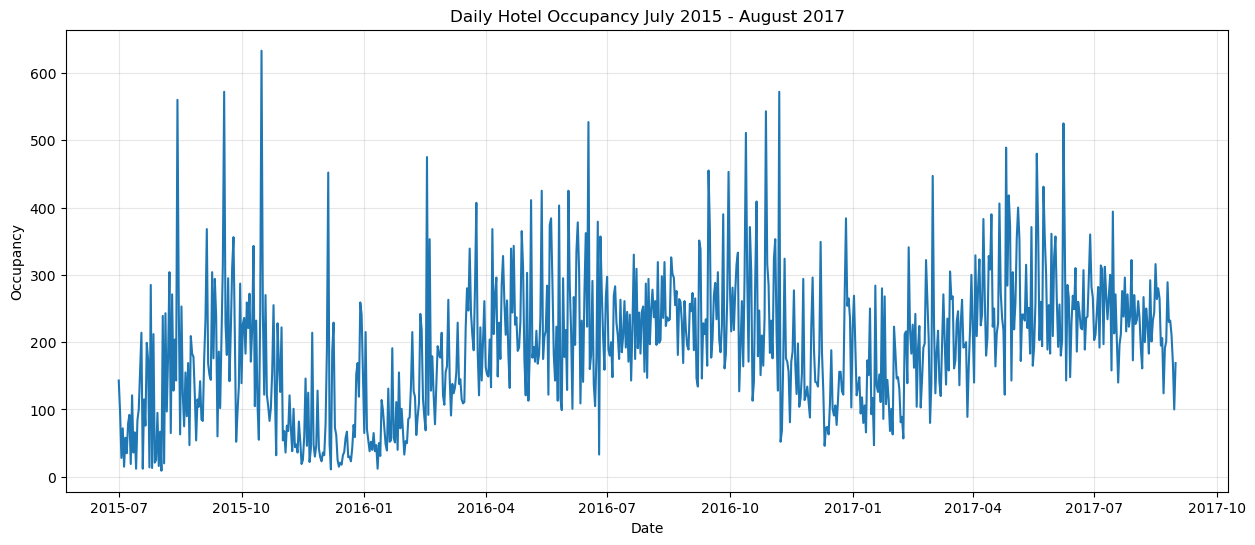

In [32]:
#PLOT 1
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_final, x="date", y="occupancy")
plt.title("Daily Hotel Occupancy July 2015 - August 2017")
plt.xlabel("Date")
plt.ylabel("Occupancy")
plt.grid(True, alpha=0.3)
plt.show()

PLOT 2: The staffing levels can be seen per day, this shows in average how many guests do we have per day and which days the staff is more busy, this  indicates that the days of the week are a stong predictor. While the days are a bit volatile, when aggregated, they reveals a clear pick demand on Thurday, Friday, Saturday and Monday.  

In [36]:
df_final["day_of_week"] = df_final["date"].dt.day_name() #dt.day_name() calls "what day of the week was on July 1st" 
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"] #I organise the days according to the week so they dont appear alphabetically
df_final["day_of_week"] = pd.Categorical(df_final["day_of_week"], categories=days_order, ordered=True)

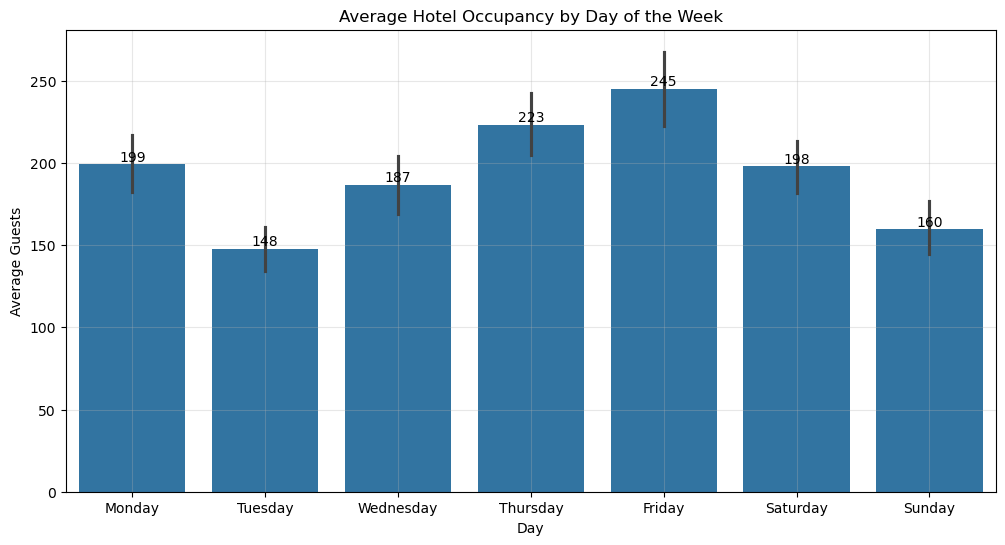

In [37]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_final, x="day_of_week", y="occupancy") # Calculate the average guests for each day
ax.bar_label(ax.containers[0], fmt="%.0f")

plt.title("Average Hotel Occupancy by Day of the Week")
plt.ylabel("Average Guests")
plt.xlabel("Day")
plt.grid(True, alpha=0.3)
plt.show()

PLOT 3
This box plot have a huge aportation to this project, it indicates that on days where there is No event (0.0), the hotel had high occupancy, could be probably the good weather or a bank holiday, but also means that is hard to predict how many guest we could have in a normal day since the information looks spread, going from a minimum of probably 10 guests to 470, and the outliners indicates even more  than 600 guests.  
It shows that on days where big events are present (2.0), the occupancy increase, proving that definetely the media of occupancy is arround 240, probably 50 more than a normal day, although, the days with small events (1.0), the occupancy is not really afected, is showing less impact that I expected. 

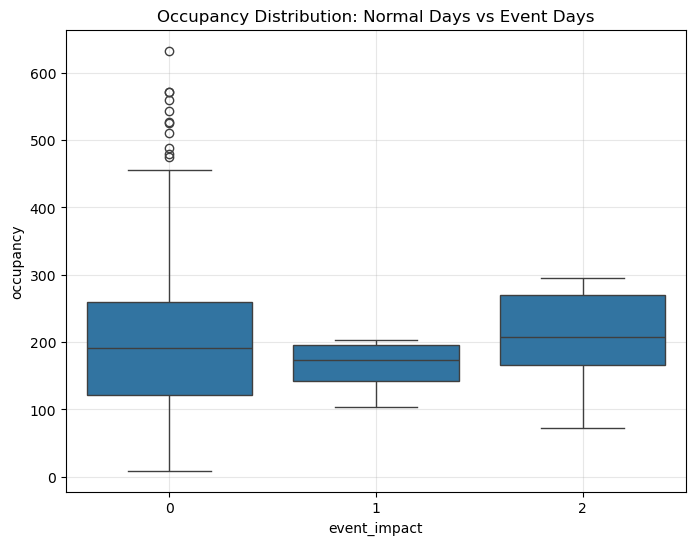

In [38]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_final, x="event_impact", y="occupancy")
plt.title("Occupancy Distribution: Normal Days vs Event Days")
plt.grid(True, alpha=0.3)
plt.show()

PLOT 4: This line plot ilustrate the clear seasonbality for the hotel. This indicates that summer time will be the peak of the occupancy whereas winter time does not have much of impact. This suggest that the baseline of number of employees scheduled for a normal day should be adjusted according to the season. The baseline for a Monday in August must be higher that a monday in January. 

In [39]:
df_final["month_num"] = df_final["date"].dt.month #

month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"} #I map the months again to be able to use them for this plot

df_final["month_name"] = df_final["month_num"].map(month_names)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] # I ordered them so they dont appear alphabetically
df_final["month_name"] = pd.Categorical(df_final["month_name"], categories=month_order, ordered=True)



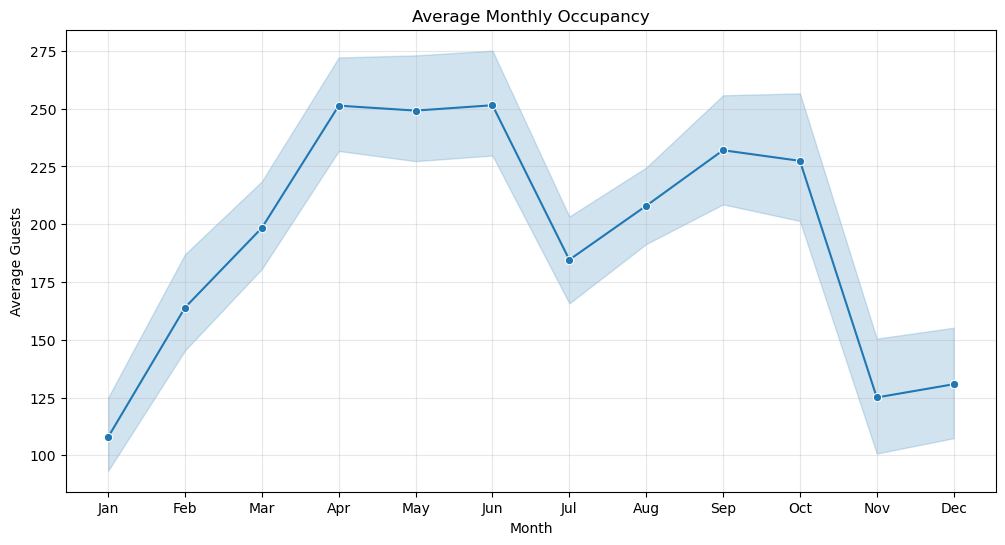

In [40]:
# Create the Line Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x="month_name", y="occupancy", marker="o",)
plt.title("Average Monthly Occupancy")
plt.ylabel("Average Guests")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.show()